# California Housing Price Prediction  
Using TensorFlow & Scikit-Learn

This notebook builds a regression model using the California Housing dataset.  
The workflow includes data loading, preprocessing, one-hot encoding, feature scaling, model building, and evaluation.


## Loading the Dataset

We load the California Housing dataset, which includes numerical features (latitude, longitude, population, etc.) and a categorical feature `ocean_proximity`.  
The target variable is **median_house_value**, the median price of houses in each district.


In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pandas as pd

2025-12-02 08:58:17.200690: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2025-12-02 08:58:17.206721: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-12-02 08:58:17.530942: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-12-02 08:58:19.687415: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off,

In [2]:
#import the data
df = pd.read_csv("../../data/CaliforniaHousingPrices.csv")
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [4]:
df.dropna(inplace=True) # remove missing values
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 20433 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20433 non-null  float64
 1   latitude            20433 non-null  float64
 2   housing_median_age  20433 non-null  float64
 3   total_rooms         20433 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20433 non-null  float64
 6   households          20433 non-null  float64
 7   median_income       20433 non-null  float64
 8   median_house_value  20433 non-null  float64
 9   ocean_proximity     20433 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.7+ MB


array([[<Axes: title={'center': 'longitude'}>,
        <Axes: title={'center': 'latitude'}>,
        <Axes: title={'center': 'housing_median_age'}>],
       [<Axes: title={'center': 'total_rooms'}>,
        <Axes: title={'center': 'total_bedrooms'}>,
        <Axes: title={'center': 'population'}>],
       [<Axes: title={'center': 'households'}>,
        <Axes: title={'center': 'median_income'}>,
        <Axes: title={'center': 'median_house_value'}>]], dtype=object)

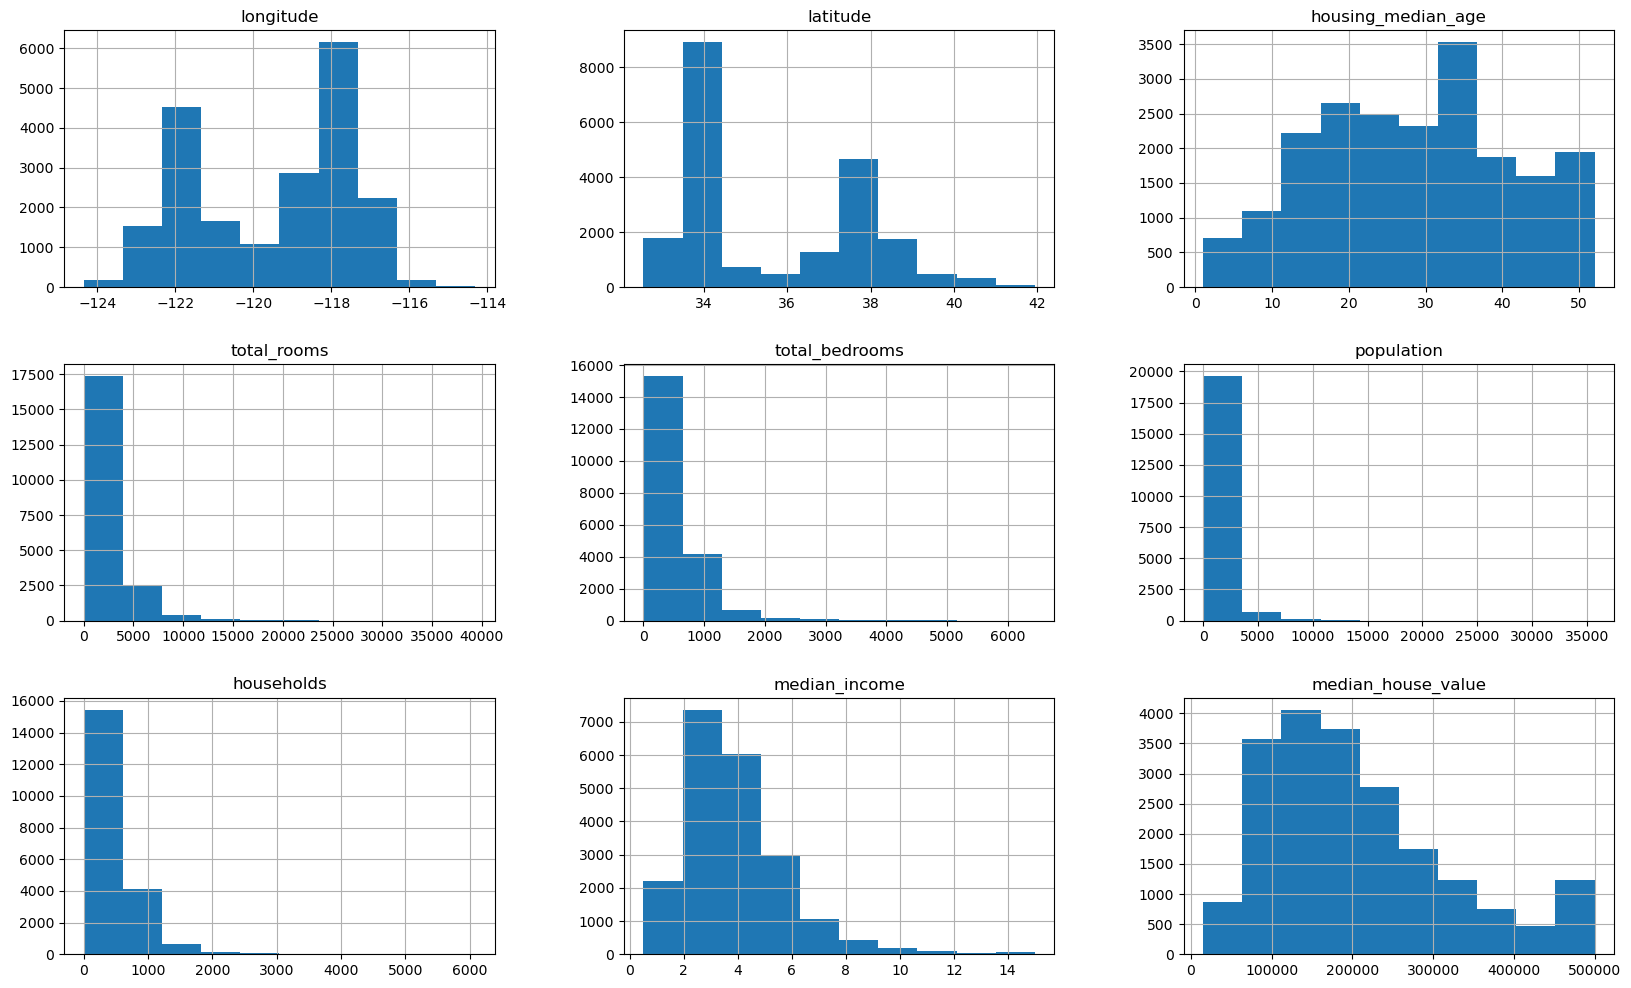

In [5]:
df.hist(figsize=(20,12))

##  Data Preprocessing

###  Handling Categorical Feature
The feature `ocean_proximity` is categorical, so we apply **One-Hot Encoding** to convert it into numerical columns.

###  Defining Features and Target
- **X**: all input features  
- **y**: `median_house_value`

###  Train/Validation Split
We split the dataset into:
- 80% training
- 20% validation


In [6]:
# we have ocean_proximity not a numerical value so we will use one-hot encoding for it and remove the column
df_encoded = df.join(pd.get_dummies(df.ocean_proximity, dtype="int")).drop(["ocean_proximity"], axis=1)
df_encoded.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,<1H OCEAN,INLAND,ISLAND,NEAR BAY,NEAR OCEAN
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,0,0,0,1,0
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,0,0,0,1,0
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,0,0,0,1,0
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,0,0,0,1,0
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,0,0,0,1,0


In [7]:
# defining the features (X) and the target output (y)
X = df_encoded.drop("median_house_value", axis=1)
y = df_encoded["median_house_value"]

# split the data into train and validate
X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, random_state=42)

## Feature Scaling

Neural networks train more efficiently when features are normalized.

We use **StandardScaler** to standardize all numerical features to mean = 0 and standard deviation = 1.

In [8]:
# normalization for the data
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_valid = scaler.fit_transform(X_valid)

y_train = scaler.fit_transform(y_train.values.reshape(-1,1))
y_valid = scaler.transform(y_valid.values.reshape(-1,1))

## Building the Neural Network

We create a simple feed-forward neural network with:

- Dense(64, relu)
- Dense(32, relu)
- Dense(1) output for regression

The model uses:
- **Adam optimizer**
- **MAE loss** (Mean Absolute Error)
- **MAE metric** (Mean Absolute Error)


In [16]:
# create the model after scaling
model = keras.Sequential([
    keras.Input(shape=[X_train.shape[1]]),
    layers.Dense(64, activation="relu"),
    layers.Dense(64, activation="relu"),
    layers.Dense(64, activation="relu"),
    layers.Dense(64, activation="relu"),
    layers.Dense(64, activation="relu"),
    layers.Dense(1),
])

In [17]:
# compile the model
model.compile(
    optimizer="adam",
    loss="mae",
    metrics=['mae']
)

## Training the Model

We train the model for 20 epochs using:

- Batch size: 32  
- 10% training data used as validation  
- Verbose output for progress tracking

Training outputs:
- **loss**: MAE on training data  
- **val_loss**: MAE on validation data  
- **mae**: Mean absolute error (more interpretable)


In [18]:
# train the model
history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.1,
    verbose=2
)

Epoch 1/20
460/460 - 3s - 6ms/step - loss: 0.4109 - mae: 0.4109 - val_loss: 0.3870 - val_mae: 0.3870
Epoch 2/20
460/460 - 2s - 4ms/step - loss: 0.3578 - mae: 0.3578 - val_loss: 0.3508 - val_mae: 0.3508
Epoch 3/20
460/460 - 1s - 3ms/step - loss: 0.3394 - mae: 0.3394 - val_loss: 0.3490 - val_mae: 0.3490
Epoch 4/20
460/460 - 2s - 4ms/step - loss: 0.3358 - mae: 0.3358 - val_loss: 0.3503 - val_mae: 0.3503
Epoch 5/20
460/460 - 2s - 4ms/step - loss: 0.3272 - mae: 0.3272 - val_loss: 0.3499 - val_mae: 0.3499
Epoch 6/20
460/460 - 1s - 3ms/step - loss: 0.3228 - mae: 0.3228 - val_loss: 0.3342 - val_mae: 0.3342
Epoch 7/20
460/460 - 2s - 4ms/step - loss: 0.3175 - mae: 0.3175 - val_loss: 0.3318 - val_mae: 0.3318
Epoch 8/20
460/460 - 1s - 3ms/step - loss: 0.3129 - mae: 0.3129 - val_loss: 0.3150 - val_mae: 0.3150
Epoch 9/20
460/460 - 2s - 4ms/step - loss: 0.3088 - mae: 0.3088 - val_loss: 0.3201 - val_mae: 0.3201
Epoch 10/20
460/460 - 2s - 4ms/step - loss: 0.3062 - mae: 0.3062 - val_loss: 0.3125 - val_m

In [19]:
# now evaluate the model
test_loss, test_mae = model.evaluate(X_valid, y_valid, verbose=0)
print(f"Test MAE: {test_mae:.3f}")

Test MAE: 0.305


In [20]:
# make predection
preds = model.predict(X_valid[:5])
print("Predected prices: ", preds.flatten())
print("Actual Prices: ", y_valid[:5])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step
Predected prices:  [-0.35023186 -0.4892887   0.0084889  -0.6242554  -0.03594217]
Actual Prices:  [[ 0.34033067]
 [-0.59750912]
 [ 0.10043838]
 [ 0.12303693]
 [-0.31415808]]


In [21]:
from sklearn.metrics import r2_score
y_pred = model.predict(X_valid)
r2 = r2_score(y_valid, y_pred)
print("Valid R2 Score: ", r2)

128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Valid R2 Score:  0.7811856952939493


In [22]:
y_pred = model.predict(X_train)
r2 = r2_score(y_train, y_pred)
print("Trained R2 score: ", r2)

511/511 ━━━━━━━━━━━━━━━━━━━━ 0s 863us/step
Trained R2 score:  0.802842015312441
